<a href="https://colab.research.google.com/github/saadmansakib75/Explainable-Deep-Learning-for-Liver-Fibrosis-Staging-Using-Attention-Augmented-CNN/blob/main/Explainable_Deep_Learning_for_Liver_Fibrosis_Staging_Using_Attention_Augmented_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Sep 27 07:53:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ==========================================
# STEP 2: UPLOAD DATASET ZIP FILE
# ==========================================

from google.colab import files

uploaded = files.upload()

# Uploaded ZIP filename
zip_name = next(iter(uploaded.keys()))

print("Uploaded file:", zip_name)

Saving kaggle.json to kaggle.json
Uploaded file: kaggle.json


In [4]:
# =====================================================
# : Download Liver Fibrosis Dataset
# =====================================================

!kaggle datasets download \
-d vibhingupta028/liver-histopathology-fibrosis-ultrasound-images

Dataset URL: https://www.kaggle.com/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images
License(s): CC-BY-SA-4.0
100% 205M/205M [00:01<00:00, 143MB/s]



In [5]:
# =====================================================
# : Extract Dataset
# =====================================================

!unzip -oq liver-histopathology-fibrosis-ultrasound-images.zip

In [7]:
# ============================================================
# STEP 1: CHECK DATASET FOLDER STRUCTURE
# ============================================================

import os

# Dataset যেখানে unzip করেছো সেই path এখানে দাও
DATASET_PATH = "/content/Dataset/Dataset"

# Dataset-এর ভিতরের files/folders দেখানো
print("Dataset path:", DATASET_PATH)
print("\nContents:")

for item in os.listdir(DATASET_PATH):
    print(item)

Dataset path: /content/Dataset/Dataset

Contents:
F1
F2
F0
F3
F4


In [23]:
# ============================================================
# STEP 2: CHECK NUMBER OF IMAGES IN EACH CLASS
# ============================================================

import os

# Dataset path
DATASET_PATH = "/content/Dataset/Dataset"

# Dataset-এর 5টি class
classes = sorted(os.listdir(DATASET_PATH))

print("Classes:", classes)
print()

# প্রতিটি class-এর image count বের করা
for class_name in classes:

    # Current class-এর folder path
    class_path = os.path.join(DATASET_PATH, class_name)

    # Folder-এর ভিতরের files
    images = os.listdir(class_path)

    # Image সংখ্যা
    print(f"{class_name}: {len(images)} images")

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']

F0: 2114 images
F1: 861 images
F2: 793 images
F3: 857 images
F4: 1698 images


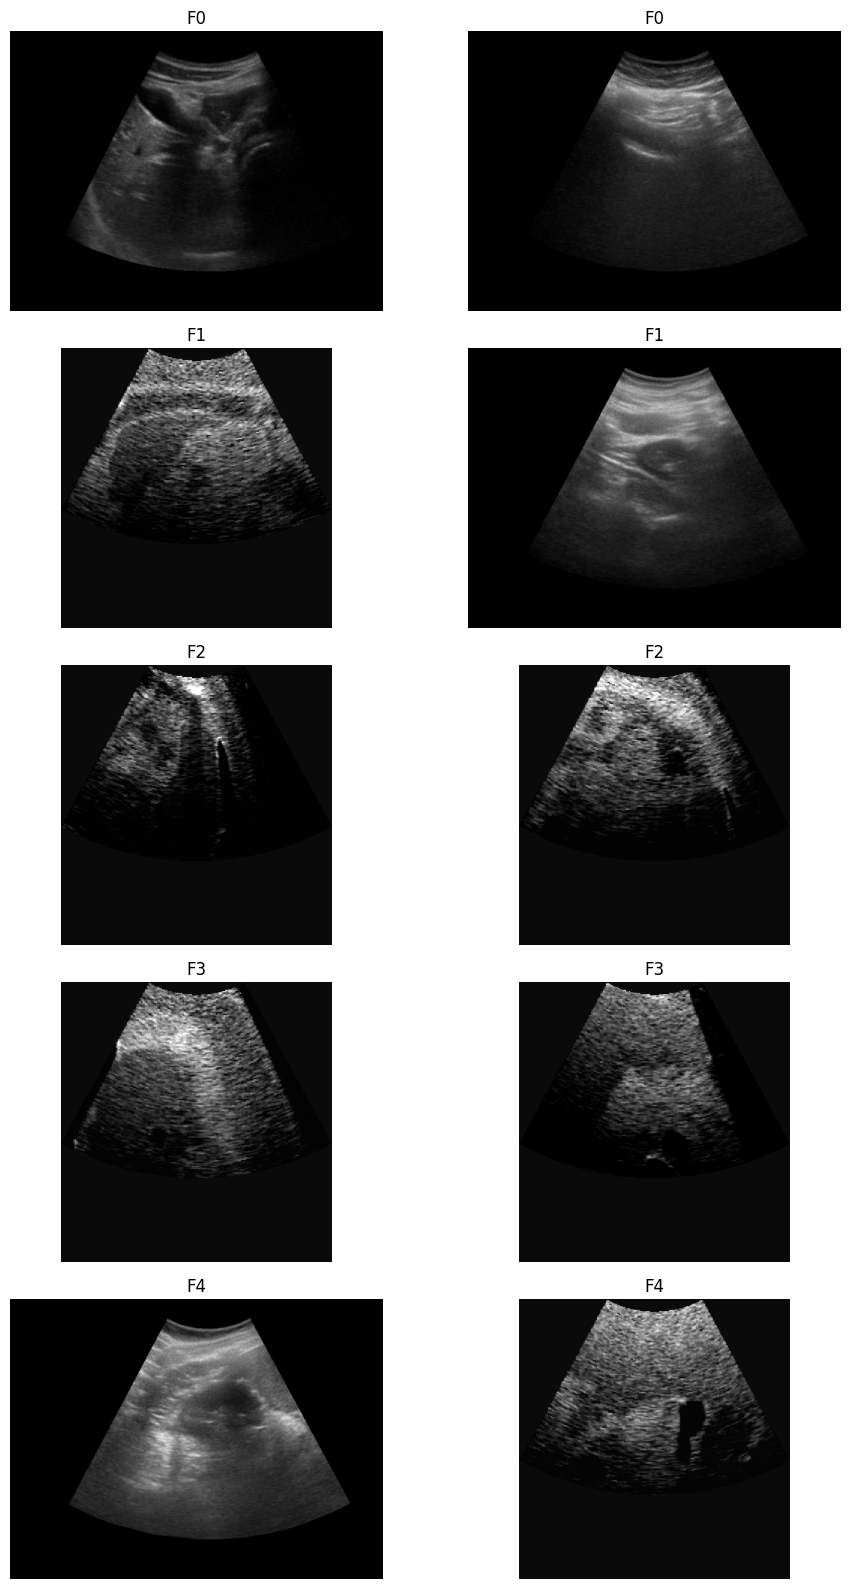

In [24]:
# ============================================================
# STEP 3: VISUALIZE SAMPLE IMAGES FROM ALL 5 CLASSES
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset-এর main folder path
DATASET_PATH = "/content/Dataset/Dataset"

# একই ফলাফল বারবার পাওয়ার জন্য random seed
random.seed(42)

# Dataset-এর class names
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

# প্রতিটি class থেকে কয়টি image দেখাব
SAMPLES_PER_CLASS = 2

# 5 classes × 2 images = 10 images
fig, axes = plt.subplots(
    len(classes),
    SAMPLES_PER_CLASS,
    figsize=(10, 16)
)

# প্রতিটি class-এর image দেখানো
for row, class_name in enumerate(classes):

    # Current class-এর folder path
    class_path = os.path.join(DATASET_PATH, class_name)

    # Folder-এর image files নির্বাচন
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    # Class-এ image না থাকলে error দেখানো
    if len(image_files) == 0:
        print(f"Warning: No images found in {class_name}")
        continue

    # Available images থেকে 2টি random image নেওয়া
    selected_images = random.sample(
        image_files,
        min(SAMPLES_PER_CLASS, len(image_files))
    )

    # নির্বাচিত image-গুলো display করা
    for col, image_name in enumerate(selected_images):

        # Image-এর complete path
        image_path = os.path.join(class_path, image_name)

        # Image open করে RGB format-এ convert করা
        img = Image.open(image_path).convert("RGB")

        # Image display করা
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

# Layout সুন্দর করা
plt.tight_layout()
plt.show()

In [25]:

# ============================================================
# STEP 4: SPLIT EACH CLASS INTO 70% TRAIN AND 30% TEST
# ============================================================

import os
import random
import shutil
import math

# Step 4.1: Original dataset path
SOURCE_DIR = "/content/Dataset/Dataset"

# Step 4.2: New directory for split dataset
OUTPUT_DIR = "/content/Dataset_split"

# Step 4.3: Define split ratio
TRAIN_RATIO = 0.70
TEST_RATIO = 0.30

# Step 4.4: Set random seed for reproducibility
random.seed(42)

# Step 4.5: Supported image formats
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
)

# Step 4.6: Get all class folders
classes = sorted([
    folder for folder in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, folder))
])

# Step 4.7: Create train and test folders for each class
for class_name in classes:

    source_class_dir = os.path.join(SOURCE_DIR, class_name)

    train_class_dir = os.path.join(
        OUTPUT_DIR, "train", class_name
    )

    test_class_dir = os.path.join(
        OUTPUT_DIR, "test", class_name
    )

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Collect image filenames
    image_files = [
        file for file in os.listdir(source_class_dir)
        if file.lower().endswith(IMAGE_EXTENSIONS)
        and os.path.isfile(os.path.join(source_class_dir, file))
    ]

    # Shuffle images within this class
    random.shuffle(image_files)

    # Calculate 70% training images
    train_count = math.floor(len(image_files) * TRAIN_RATIO)

    # Split filenames into train and test
    train_files = image_files[:train_count]
    test_files = image_files[train_count:]

    # Copy training images
    for filename in train_files:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(train_class_dir, filename)
        )

    # Copy testing images
    for filename in test_files:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(test_class_dir, filename)
        )

    # Print split summary for this class
    print(f"\nClass: {class_name}")
    print(f"Total images: {len(image_files)}")
    print(f"Train images: {len(train_files)}")
    print(f"Test images:  {len(test_files)}")

print("\nDataset split completed!")
print("Output directory:", OUTPUT_DIR)


Class: F0
Total images: 2114
Train images: 1479
Test images:  635

Class: F1
Total images: 861
Train images: 602
Test images:  259

Class: F2
Total images: 793
Train images: 555
Test images:  238

Class: F3
Total images: 857
Train images: 599
Test images:  258

Class: F4
Total images: 1698
Train images: 1188
Test images:  510

Dataset split completed!
Output directory: /content/Dataset_split


In [26]:

# ============================================================
# STEP 5: MERGE ALL CLASSES INTO TRAIN AND TEST FOLDERS
# ============================================================

import os
import shutil

# Existing split dataset
SOURCE_DIR = "/content/Dataset_split"

# Destination folders
OUTPUT_DIR = "/content/Dataset_merged"

TRAIN_SOURCE = os.path.join(SOURCE_DIR, "train")
TEST_SOURCE = os.path.join(SOURCE_DIR, "test")

TRAIN_DEST = os.path.join(OUTPUT_DIR, "train")
TEST_DEST = os.path.join(OUTPUT_DIR, "test")

# Create destination folders
os.makedirs(TRAIN_DEST, exist_ok=True)
os.makedirs(TEST_DEST, exist_ok=True)

# Supported image extensions
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
)

# Function to merge images from all classes
def merge_classes(source_dir, destination_dir):

    total_images = 0

    # Loop through each class folder
    for class_name in sorted(os.listdir(source_dir)):

        class_dir = os.path.join(source_dir, class_name)

        if not os.path.isdir(class_dir):
            continue

        # Loop through images in the class folder
        for filename in sorted(os.listdir(class_dir)):

            if not filename.lower().endswith(IMAGE_EXTENSIONS):
                continue

            source_path = os.path.join(class_dir, filename)

            # Prefix filename with class name to preserve label
            new_filename = f"{class_name}_{filename}"

            destination_path = os.path.join(
                destination_dir, new_filename
            )

            # Copy image to merged folder
            shutil.copy2(source_path, destination_path)

            total_images += 1

    return total_images


# Merge training images
train_count = merge_classes(TRAIN_SOURCE, TRAIN_DEST)

# Merge testing images
test_count = merge_classes(TEST_SOURCE, TEST_DEST)

# Display results
print("Merge completed successfully!")
print("Merged training images:", train_count)
print("Merged testing images:", test_count)

print("\nOutput structure:")
print(OUTPUT_DIR)
print("  ├── train/  (all training images)")
print("  └── test/   (all testing images)")

Merge completed successfully!
Merged training images: 4423
Merged testing images: 1900

Output structure:
/content/Dataset_merged
  ├── train/  (all training images)
  └── test/   (all testing images)


In [27]:

# ============================================================
# STEP 7: RESIZE + ALL SELECTED DATA AUGMENTATIONS
# ============================================================

import os
import random
import numpy as np
import torch

from PIL import Image
from torchvision import transforms
from torchvision.transforms import functional as TF

# ------------------------------------------------------------
# 7.1: DEFINE INPUT AND OUTPUT PATHS
# ------------------------------------------------------------

TRAIN_DIR = "/content/Dataset_merged/train"
TEST_DIR = "/content/Dataset_merged/test"

OUTPUT_DIR = "/content/Dataset_final_v2"

TRAIN_OUT = os.path.join(OUTPUT_DIR, "train")
TEST_OUT = os.path.join(OUTPUT_DIR, "test")

os.makedirs(TRAIN_OUT, exist_ok=True)
os.makedirs(TEST_OUT, exist_ok=True)

# ------------------------------------------------------------
# 7.2: SET RANDOM SEEDS
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# 7.3: DEFINE IMAGE SETTINGS
# ------------------------------------------------------------

TARGET_SIZE = (224, 224)

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
)

# ------------------------------------------------------------
# 7.4: DEFINE GEOMETRIC AND COLOR AUGMENTATIONS
# Applied to training images only
# ------------------------------------------------------------

augmentation = transforms.Compose([

    # Resize all images to 224 x 224
    transforms.Resize(TARGET_SIZE),

    # Random rotation between -20 and +20 degrees
    transforms.RandomRotation(
        degrees=20,
        fill=0
    ),

    # Random horizontal flip with 50% probability
    transforms.RandomHorizontalFlip(p=0.5),

    # Slight brightness and contrast variation
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    # Slight translation and scaling
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        fill=0
    )
])

# ------------------------------------------------------------
# 7.5: PROCESS TRAINING IMAGES
# Save both resized original and augmented copy
# ------------------------------------------------------------

train_files = sorted([
    f for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
    and os.path.isfile(os.path.join(TRAIN_DIR, f))
])

original_count = 0
augmented_count = 0

for filename in train_files:

    input_path = os.path.join(TRAIN_DIR, filename)

    try:
        # Open original image
        with Image.open(input_path) as img:
            image = img.convert("RGB")

        # Resize original image without augmentation
        resized_image = image.resize(
            TARGET_SIZE,
            Image.Resampling.LANCZOS
        )

        # Save resized original training image
        original_name, _ = os.path.splitext(filename)

        original_path = os.path.join(
            TRAIN_OUT,
            original_name + ".jpg"
        )

        resized_image.save(original_path, quality=95)
        original_count += 1

        # Apply all selected augmentations
        augmented_image = augmentation(image)

        # Convert to tensor to add slight Gaussian noise
        image_tensor = TF.to_tensor(augmented_image)

        # Gaussian noise with small standard deviation
        noise = torch.randn_like(image_tensor) * 0.01

        # Add noise and keep pixel values in [0, 1]
        noisy_tensor = torch.clamp(
            image_tensor + noise,
            min=0.0,
            max=1.0
        )

        # Convert back to PIL image
        final_augmented = TF.to_pil_image(noisy_tensor)

        # Save one augmented copy
        augmented_path = os.path.join(
            TRAIN_OUT,
            original_name + "_aug1.jpg"
        )

        final_augmented.save(
            augmented_path,
            quality=95
        )

        augmented_count += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# ------------------------------------------------------------
# 7.6: PROCESS TEST IMAGES
# Resize only. No augmentation or noise.
# ------------------------------------------------------------

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
    and os.path.isfile(os.path.join(TEST_DIR, f))
])

test_count = 0

for filename in test_files:

    input_path = os.path.join(TEST_DIR, filename)

    try:
        with Image.open(input_path) as img:
            image = img.convert("RGB")

        # Resize test image only
        image = image.resize(
            TARGET_SIZE,
            Image.Resampling.LANCZOS
        )

        output_path = os.path.join(
            TEST_OUT,
            os.path.splitext(filename)[0] + ".jpg"
        )

        image.save(output_path, quality=95)
        test_count += 1

    except Exception as e:
        print(f"Error processing test image {filename}: {e}")

# ------------------------------------------------------------
# 7.7: PRINT SUMMARY
# ------------------------------------------------------------

print("\n========== STEP 7 SUMMARY ==========")
print("Target image size:", TARGET_SIZE)
print("Original training images:", original_count)
print("Augmented training images:", augmented_count)
print("Total training images:", original_count + augmented_count)
print("Test images (resize only):", test_count)
print("Output directory:", OUTPUT_DIR)
print("====================================")



========== STEP 7 SUMMARY ==========
Target image size: (224, 224)
Original training images: 4423
Augmented training images: 4423
Total training images: 8846
Test images (resize only): 1900
Output directory: /content/Dataset_final_v2


In [28]:

# ============================================================
# STEP 8: CREATE LABELS AND PREPARE PYTORCH DATALOADERS
# ============================================================

import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------
# 8.1: DEFINE DATASET PATHS
# ------------------------------------------------------------

TRAIN_DIR = "/content/Dataset_final_v2/train"
TEST_DIR = "/content/Dataset_final_v2/test"

# Class names and numeric labels
CLASS_NAMES = ["F0", "F1", "F2", "F3", "F4"]

CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

print("Class mapping:", CLASS_TO_IDX)

# ------------------------------------------------------------
# 8.2: DEFINE IMAGE TRANSFORM
# Images are already resized to 224 x 224
# Normalize for pretrained ImageNet models
# ------------------------------------------------------------

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# 8.3: CREATE DATAFRAME FROM FILENAMES
# Filename prefix identifies the class
# Example: F0_image123.jpg -> class F0
# ------------------------------------------------------------

def create_dataframe(folder):

    records = []

    for filename in sorted(os.listdir(folder)):

        if not filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")
        ):
            continue

        # Extract class prefix from filename
        class_name = filename.split("_", 1)[0]

        # Skip files with unknown class prefixes
        if class_name not in CLASS_TO_IDX:
            print("Skipping unknown class:", filename)
            continue

        records.append({
            "image_path": os.path.join(folder, filename),
            "class_name": class_name,
            "label": CLASS_TO_IDX[class_name]
        })

    return pd.DataFrame(records)


train_df = create_dataframe(TRAIN_DIR)
test_df = create_dataframe(TEST_DIR)

# ------------------------------------------------------------
# 8.4: VERIFY CLASS COUNTS
# ------------------------------------------------------------

print("\nTraining image counts:")
print(train_df["class_name"].value_counts().sort_index())

print("\nTest image counts:")
print(test_df["class_name"].value_counts().sort_index())

print("\nTotal training images:", len(train_df))
print("Total test images:", len(test_df))

# ------------------------------------------------------------
# 8.5: CREATE PYTORCH DATASET
# ------------------------------------------------------------

class UltrasoundDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load image
        image = Image.open(row["image_path"]).convert("RGB")

        # Apply normalization and tensor conversion
        if self.transform:
            image = self.transform(image)

        # Numeric class label
        label = int(row["label"])

        return image, label


# ------------------------------------------------------------
# 8.6: CREATE DATASET OBJECTS
# ------------------------------------------------------------

train_dataset = UltrasoundDataset(
    train_df,
    transform=image_transform
)

test_dataset = UltrasoundDataset(
    test_df,
    transform=image_transform
)

# ------------------------------------------------------------
# 8.7: CREATE DATALOADERS
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# 8.8: VERIFY ONE BATCH
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

print("\nStep 8 completed successfully!")

Class mapping: {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}

Training image counts:
class_name
F0    2958
F1    1204
F2    1110
F3    1198
F4    2376
Name: count, dtype: int64

Test image counts:
class_name
F0    635
F1    259
F2    238
F3    258
F4    510
Name: count, dtype: int64

Total training images: 8846
Total test images: 1900

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: [0, 2, 0, 4, 0, 0, 0, 4, 3, 0]

Step 8 completed successfully!


In [29]:

# ============================================================
# STEP 9: CREATE LEAKAGE-FREE TRAIN / VALIDATION SPLIT
# ============================================================

import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Step 9.1: Identify original and augmented images
# Augmented filenames end with "_aug1"

train_df = train_df.copy()

train_df["filename"] = train_df["image_path"].apply(
    os.path.basename
)

train_df["stem"] = train_df["filename"].apply(
    lambda x: os.path.splitext(x)[0]
)

train_df["is_augmented"] = train_df["stem"].str.endswith("_aug1")

# Step 9.2: Keep original images for splitting
original_df = train_df[
    ~train_df["is_augmented"]
].copy()

# Group identifier: remove augmentation suffix if present
original_df["group_id"] = original_df["stem"]

# Step 9.3: Split original images into train and validation
train_original_df, val_df = train_test_split(
    original_df,
    test_size=0.10,
    random_state=42,
    stratify=original_df["label"]
)

# Step 9.4: Keep augmented copies only for training originals
train_group_ids = set(train_original_df["group_id"])

augmented_df = train_df[
    train_df["is_augmented"]
].copy()

augmented_df["group_id"] = augmented_df["stem"].str.replace(
    r"_aug1$", "", regex=True
)

augmented_for_train = augmented_df[
    augmented_df["group_id"].isin(train_group_ids)
].copy()

# Combine original training images with their augmented copies
final_train_df = __import__("pandas").concat(
    [train_original_df, augmented_for_train],
    ignore_index=True
)

# Step 9.5: Create PyTorch datasets
train_dataset = UltrasoundDataset(
    final_train_df,
    transform=image_transform
)

val_dataset = UltrasoundDataset(
    val_df,
    transform=image_transform
)

# Step 9.6: Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# Keep the existing test_loader unchanged

# Step 9.7: Print split summary
print("Original training images:", len(original_df))
print("Training images including augmentation:", len(final_train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nValidation class counts:")
print(val_df["class_name"].value_counts().sort_index())

print("\nStep 9 completed!")

Original training images: 4423
Training images including augmentation: 7960
Validation images: 443
Test images: 1900

Validation class counts:
class_name
F0    148
F1     60
F2     56
F3     60
F4    119
Name: count, dtype: int64

Step 9 completed!


In [30]:

# ============================================================
# STEP 9: CREATE LEAKAGE-FREE TRAIN / VALIDATION SPLIT
# ============================================================

import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Step 9.1: Identify original and augmented images
# Augmented filenames end with "_aug1"

train_df = train_df.copy()

train_df["filename"] = train_df["image_path"].apply(
    os.path.basename
)

train_df["stem"] = train_df["filename"].apply(
    lambda x: os.path.splitext(x)[0]
)

train_df["is_augmented"] = train_df["stem"].str.endswith("_aug1")

# Step 9.2: Keep original images for splitting
original_df = train_df[
    ~train_df["is_augmented"]
].copy()

# Group identifier: remove augmentation suffix if present
original_df["group_id"] = original_df["stem"]

# Step 9.3: Split original images into train and validation
train_original_df, val_df = train_test_split(
    original_df,
    test_size=0.10,
    random_state=42,
    stratify=original_df["label"]
)

# Step 9.4: Keep augmented copies only for training originals
train_group_ids = set(train_original_df["group_id"])

augmented_df = train_df[
    train_df["is_augmented"]
].copy()

augmented_df["group_id"] = augmented_df["stem"].str.replace(
    r"_aug1$", "", regex=True
)

augmented_for_train = augmented_df[
    augmented_df["group_id"].isin(train_group_ids)
].copy()

# Combine original training images with their augmented copies
final_train_df = __import__("pandas").concat(
    [train_original_df, augmented_for_train],
    ignore_index=True
)

# Step 9.5: Create PyTorch datasets
train_dataset = UltrasoundDataset(
    final_train_df,
    transform=image_transform
)

val_dataset = UltrasoundDataset(
    val_df,
    transform=image_transform
)

# Step 9.6: Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# Keep the existing test_loader unchanged

# Step 9.7: Print split summary
print("Original training images:", len(original_df))
print("Training images including augmentation:", len(final_train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nValidation class counts:")
print(val_df["class_name"].value_counts().sort_index())

print("\nStep 9 completed!")

Original training images: 4423
Training images including augmentation: 7960
Validation images: 443
Test images: 1900

Validation class counts:
class_name
F0    148
F1     60
F2     56
F3     60
F4    119
Name: count, dtype: int64

Step 9 completed!


In [31]:

# Step 10: MobileNetV3-Small model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights

# GPU available thakle GPU, na hole CPU use korbe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained MobileNetV3-Small load kora
weights = MobileNet_V3_Small_Weights.DEFAULT
model = models.mobilenet_v3_small(weights=weights)

# Final classification layer 5 class-er jonno change kora
num_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("Model setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 74.3MB/s]


Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=5, bias=True)
)
Model setup complete!


In [33]:
!nvidia-smi

Sun Sep 27 08:34:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             27W /   70W |     783MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:

# Step 11: Train and validate the model

import copy
import torch

num_epochs = 10
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Gradient reset
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Loss and accuracy calculate
        running_train_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    # -------- Validation --------
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

    # Validation loss kom hole best model save kora
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_mobilenetv3_small.pth"
        )

        print("Best model saved!")

# Training seshe best model restore kora
model.load_state_dict(best_model_state)

print("\nTraining complete!")
print("Best validation loss:", round(best_val_loss, 4))
print("Model saved at: /content/best_mobilenetv3_small.pth")


Epoch [1/10]
Train Loss: 0.6896 | Train Accuracy: 0.7160
Val Loss:   0.5955 | Val Accuracy:   0.7517
Best model saved!

Epoch [2/10]
Train Loss: 0.4660 | Train Accuracy: 0.8186
Val Loss:   0.4663 | Val Accuracy:   0.8239
Best model saved!

Epoch [3/10]
Train Loss: 0.3241 | Train Accuracy: 0.8732
Val Loss:   0.4137 | Val Accuracy:   0.8262
Best model saved!

Epoch [4/10]
Train Loss: 0.2290 | Train Accuracy: 0.9132
Val Loss:   0.2069 | Val Accuracy:   0.9300
Best model saved!

Epoch [5/10]
Train Loss: 0.1544 | Train Accuracy: 0.9430
Val Loss:   0.7092 | Val Accuracy:   0.7585

Epoch [6/10]
Train Loss: 0.1051 | Train Accuracy: 0.9641
Val Loss:   0.4928 | Val Accuracy:   0.8126

Epoch [7/10]
Train Loss: 0.0832 | Train Accuracy: 0.9710
Val Loss:   0.2072 | Val Accuracy:   0.9481

Epoch [8/10]
Train Loss: 0.0609 | Train Accuracy: 0.9804
Val Loss:   0.3520 | Val Accuracy:   0.9074

Epoch [9/10]
Train Loss: 0.0520 | Train Accuracy: 0.9828
Val Loss:   0.1720 | Val Accuracy:   0.9594
Best model

Test Accuracy: 96.68%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9828    0.8803    0.9287       259
          F2     0.9550    0.8908    0.9217       238
          F3     0.9307    0.9884    0.9586       258
          F4     0.9441    0.9941    0.9685       510

    accuracy                         0.9668      1900
   macro avg     0.9625    0.9507    0.9555      1900
weighted avg     0.9676    0.9668    0.9664      1900



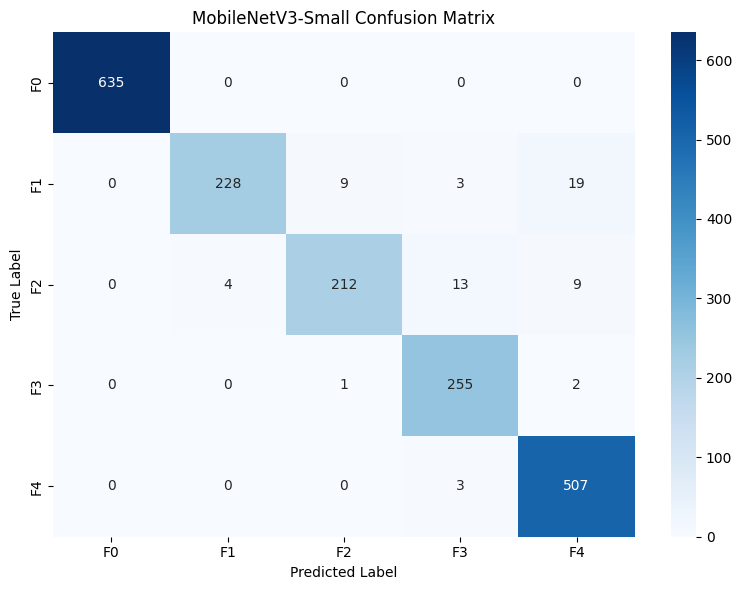

In [36]:

# Step 12: Evaluate the best model on the test dataset

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best saved model load kora
model.load_state_dict(
    torch.load(
        "/content/best_mobilenetv3_small.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

# Class names
class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

# Test set-e prediction
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Overall accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Precision, Recall, F1-score
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV3-Small Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9970
Weighted ROC-AUC: 0.9980


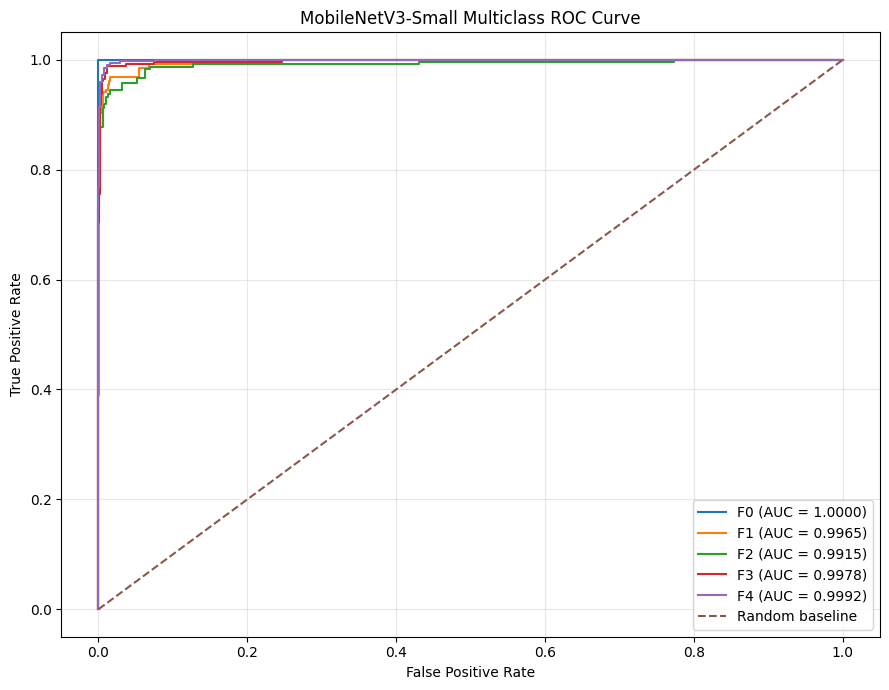

In [37]:

# Step 13: Multiclass ROC Curve and AUC

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

model.eval()

all_labels = []
all_probs = []

# Test set theke predicted probabilities collect kora
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# True labels-ke one-vs-rest binary format-e convert kora
binary_labels = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3, 4]
)

# Macro and weighted multiclass ROC-AUC
macro_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Prottek class-er ROC curve plot kora
plt.figure(figsize=(9, 7))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV3-Small Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:

# Step 14: Save evaluation results

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["F0", "F1", "F2", "F3", "F4"]

# Classification report dictionary
report = classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Classification report CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    "/content/classification_report.csv",
    index=True
)

# Confusion matrix CSV
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

cm_df.to_csv("/content/confusion_matrix.csv")

# AUC results CSV
auc_results = pd.DataFrame({
    "Metric": ["Macro ROC-AUC", "Weighted ROC-AUC"],
    "Score": [macro_auc, weighted_auc]
})

auc_results.to_csv(
    "/content/roc_auc_results.csv",
    index=False
)

print("Evaluation files saved:")
print("/content/classification_report.csv")
print("/content/confusion_matrix.csv")
print("/content/roc_auc_results.csv")

Evaluation files saved:
/content/classification_report.csv
/content/confusion_matrix.csv
/content/roc_auc_results.csv


In [39]:

# Step 15: ShuffleNetV2 x0.5 model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ShuffleNet_V2_X0_5_Weights

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained ShuffleNetV2 x0.5 load
weights = ShuffleNet_V2_X0_5_Weights.DEFAULT
model = models.shufflenet_v2_x0_5(weights=weights)

# Final layer 5-class classification-er jonno change
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.fc)
print("ShuffleNetV2 x0.5 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


100%|██████████| 5.28M/5.28M [00:00<00:00, 86.5MB/s]

Linear(in_features=1024, out_features=5, bias=True)
ShuffleNetV2 x0.5 setup complete!


In [40]:

# Step 16: Train and validate ShuffleNetV2 x0.5

import copy
import torch

num_epochs = 20
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Best model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_shufflenet_v2_x0_5.pth"
        )

        print("Best ShuffleNet model saved!")

# Best checkpoint restore
model.load_state_dict(best_model_state)

print("\nShuffleNetV2 training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/20]
Train Loss: 1.3333 | Train Accuracy: 0.4529
Val Loss:   1.1022 | Val Accuracy:   0.5102
Best ShuffleNet model saved!

Epoch [2/20]
Train Loss: 1.0070 | Train Accuracy: 0.5611
Val Loss:   0.8364 | Val Accuracy:   0.6479
Best ShuffleNet model saved!

Epoch [3/20]
Train Loss: 0.8000 | Train Accuracy: 0.6578
Val Loss:   0.6601 | Val Accuracy:   0.6975
Best ShuffleNet model saved!

Epoch [4/20]
Train Loss: 0.6577 | Train Accuracy: 0.7222
Val Loss:   0.5335 | Val Accuracy:   0.7630
Best ShuffleNet model saved!

Epoch [5/20]
Train Loss: 0.5410 | Train Accuracy: 0.7800
Val Loss:   0.4330 | Val Accuracy:   0.8239
Best ShuffleNet model saved!

Epoch [6/20]
Train Loss: 0.4552 | Train Accuracy: 0.8197
Val Loss:   0.4098 | Val Accuracy:   0.8465
Best ShuffleNet model saved!

Epoch [7/20]
Train Loss: 0.3935 | Train Accuracy: 0.8491
Val Loss:   0.3131 | Val Accuracy:   0.8758
Best ShuffleNet model saved!

Epoch [8/20]
Train Loss: 0.3330 | Train Accuracy: 0.8745
Val Loss:   0.2440 | Val 

ShuffleNetV2 Test Accuracy: 96.47%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9510    0.8996    0.9246       259
          F2     0.8798    0.9538    0.9153       238
          F3     0.9562    0.9302    0.9430       258
          F4     0.9746    0.9765    0.9755       510

    accuracy                         0.9647      1900
   macro avg     0.9523    0.9520    0.9517      1900
weighted avg     0.9655    0.9647    0.9648      1900



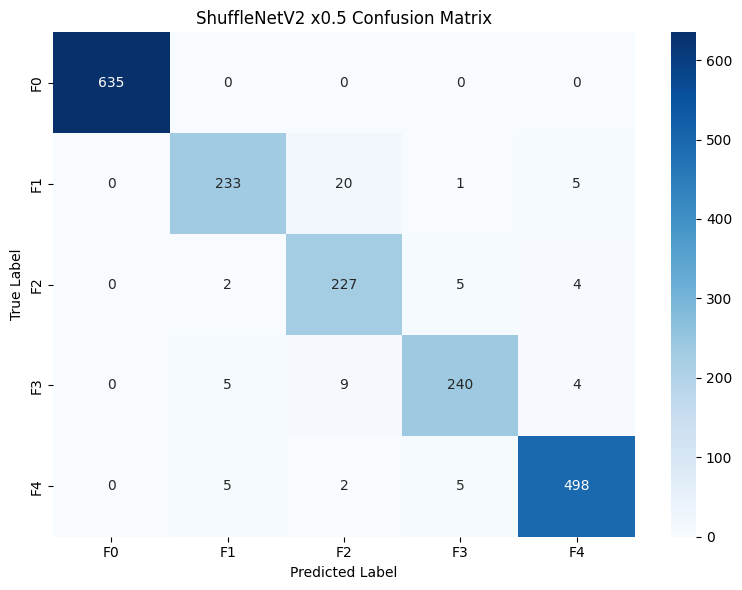

In [41]:

# Step 17: Evaluate ShuffleNetV2 x0.5

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best checkpoint load
model.load_state_dict(
    torch.load(
        "/content/best_shufflenet_v2_x0_5.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Test accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)
print(f"ShuffleNetV2 Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    digits=4,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ShuffleNetV2 x0.5 Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9950
Weighted ROC-AUC: 0.9960


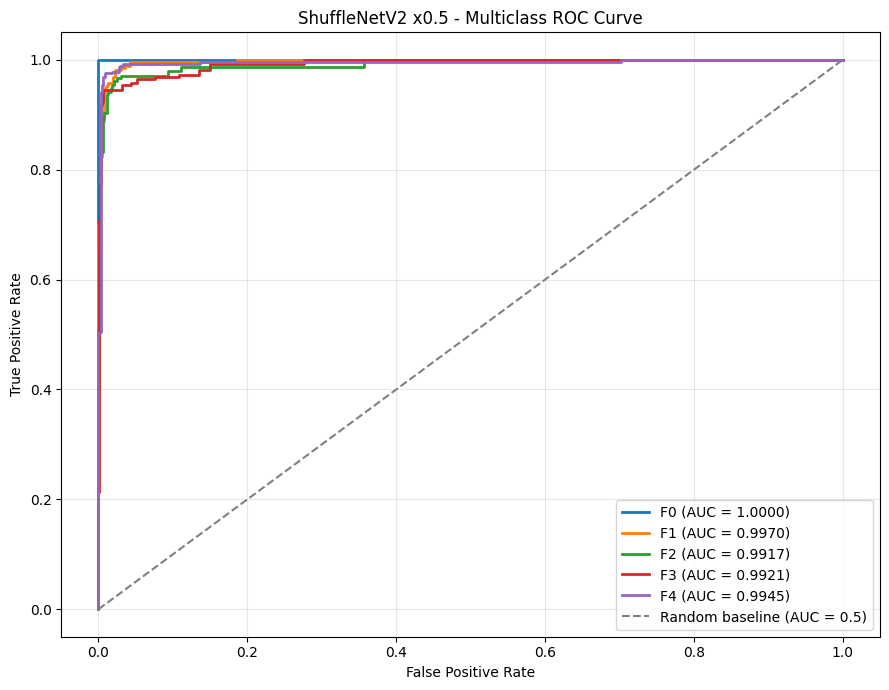

ROC curve saved: /content/shufflenet_roc_curve.png


In [42]:

# Step 20: ShuffleNetV2 x0.5 - ROC Curve and AUC

import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models
import torch.nn as nn

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Device select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

# ShuffleNetV2 x0.5 model create
roc_model = models.shufflenet_v2_x0_5(weights=None)
roc_model.fc = nn.Linear(roc_model.fc.in_features, num_classes)

# Best trained checkpoint load
roc_model.load_state_dict(
    torch.load(
        "/content/best_shufflenet_v2_x0_5.pth",
        map_location=device,
        weights_only=True
    )
)

roc_model = roc_model.to(device)
roc_model.eval()

all_labels_roc = []
all_probs_roc = []

# Test dataset theke probability collect
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = roc_model(images)

        # Logits theke class probability
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc.extend(labels.cpu().numpy())
        all_probs_roc.extend(probabilities.cpu().numpy())

all_labels_roc = np.array(all_labels_roc)
all_probs_roc = np.array(all_probs_roc)

# True labels one-vs-rest format-e convert
binary_labels = label_binarize(
    all_labels_roc,
    classes=[0, 1, 2, 3, 4]
)

# Overall multiclass AUC
macro_auc = roc_auc_score(
    binary_labels,
    all_probs_roc,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs_roc,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Plot class-wise ROC curves
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs_roc[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

# Random classifier baseline
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline (AUC = 0.5)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ShuffleNetV2 x0.5 - Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# Figure save
plt.savefig(
    "/content/shufflenet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved: /content/shufflenet_roc_curve.png")

In [43]:

# Step 22: SqueezeNet 1.1 setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import SqueezeNet1_1_Weights

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained SqueezeNet 1.1 load
weights = SqueezeNet1_1_Weights.DEFAULT
model = models.squeezenet1_1(weights=weights)

# Final convolution layer 5-class classification-er jonno change
model.classifier[1] = nn.Conv2d(
    in_channels=512,
    out_channels=5,
    kernel_size=1
)

# Model device-e pathano
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("SqueezeNet 1.1 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 56.6MB/s]

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Conv2d(512, 5, kernel_size=(1, 1), stride=(1, 1))
  (2): ReLU(inplace=True)
  (3): AdaptiveAvgPool2d(output_size=(1, 1))
)
SqueezeNet 1.1 setup complete!


In [44]:

# Step 23: Train and validate SqueezeNet 1.1

import copy
import torch

num_epochs = 25
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Best model validation loss-er basis-e save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_squeezenet1_1.pth"
        )

        print("Best SqueezeNet model saved!")

# Best model restore
model.load_state_dict(best_model_state)

print("\nSqueezeNet training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/25]
Train Loss: 0.9726 | Train Accuracy: 0.5678
Val Loss:   0.6557 | Val Accuracy:   0.7359
Best SqueezeNet model saved!

Epoch [2/25]
Train Loss: 0.6569 | Train Accuracy: 0.7219
Val Loss:   0.5436 | Val Accuracy:   0.7720
Best SqueezeNet model saved!

Epoch [3/25]
Train Loss: 0.5408 | Train Accuracy: 0.7775
Val Loss:   0.4777 | Val Accuracy:   0.8014
Best SqueezeNet model saved!

Epoch [4/25]
Train Loss: 0.4549 | Train Accuracy: 0.8137
Val Loss:   0.4212 | Val Accuracy:   0.8330
Best SqueezeNet model saved!

Epoch [5/25]
Train Loss: 0.4122 | Train Accuracy: 0.8337
Val Loss:   0.3920 | Val Accuracy:   0.8420
Best SqueezeNet model saved!

Epoch [6/25]
Train Loss: 0.3587 | Train Accuracy: 0.8597
Val Loss:   0.2956 | Val Accuracy:   0.8713
Best SqueezeNet model saved!

Epoch [7/25]
Train Loss: 0.3220 | Train Accuracy: 0.8789
Val Loss:   0.2383 | Val Accuracy:   0.9165
Best SqueezeNet model saved!

Epoch [8/25]
Train Loss: 0.2721 | Train Accuracy: 0.8967
Val Loss:   0.3625 | Val 

SqueezeNet Test Accuracy: 97.21%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9506    0.9653    0.9579       259
          F2     0.9330    0.8782    0.9048       238
          F3     0.9097    0.9767    0.9421       258
          F4     1.0000    0.9824    0.9911       510

    accuracy                         0.9721      1900
   macro avg     0.9587    0.9605    0.9592      1900
weighted avg     0.9726    0.9721    0.9721      1900



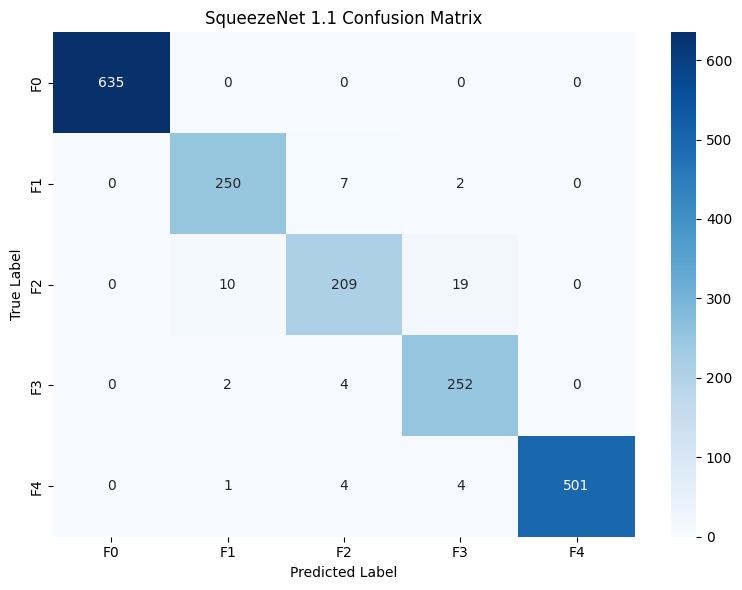

In [45]:

# Step 24: Evaluate SqueezeNet 1.1

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best checkpoint load
model.load_state_dict(
    torch.load(
        "/content/best_squeezenet1_1.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Test accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)
print(f"SqueezeNet Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    digits=4,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SqueezeNet 1.1 Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9966
Weighted ROC-AUC: 0.9975


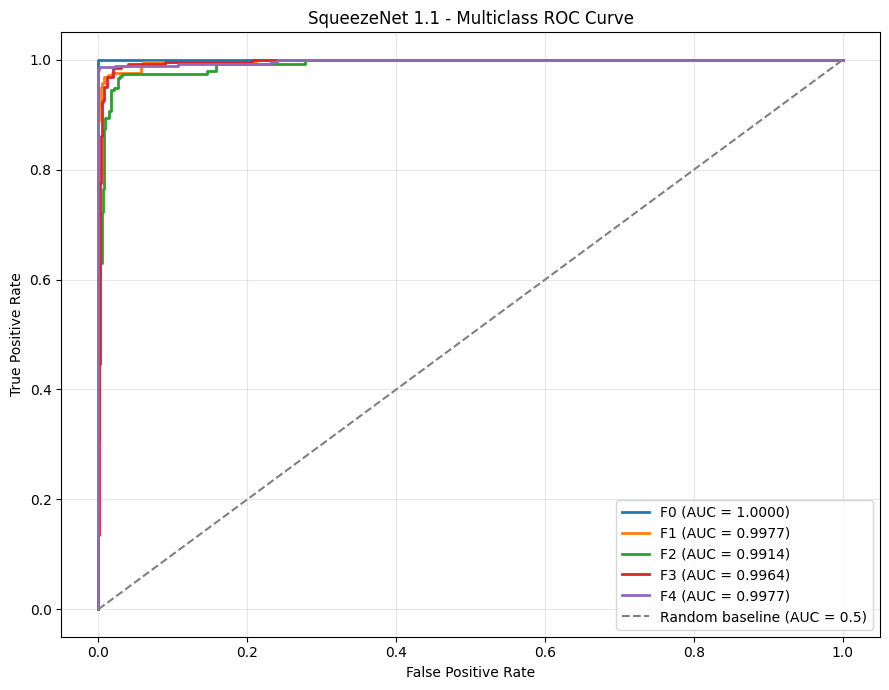

ROC curve saved successfully!


In [46]:

# Step 25: SqueezeNet 1.1 - Multiclass ROC Curve and AUC

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Device select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["F0", "F1", "F2", "F3", "F4"]
num_classes = len(class_names)

# SqueezeNet 1.1 model create
roc_model = models.squeezenet1_1(weights=None)

# 5-class output layer
roc_model.classifier[1] = nn.Conv2d(
    512, num_classes, kernel_size=1
)

# Best trained model load
roc_model.load_state_dict(
    torch.load(
        "/content/best_squeezenet1_1.pth",
        map_location=device,
        weights_only=True
    )
)

roc_model = roc_model.to(device)
roc_model.eval()

all_labels_roc = []
all_probs_roc = []

# Test dataset theke predicted probabilities collect
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = roc_model(images)

        # SqueezeNet output shape [batch, 5, 1, 1]
        # ROC calculation-er jonno [batch, 5] korte hobe
        outputs = outputs.flatten(start_dim=1)

        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc.extend(labels.cpu().numpy())
        all_probs_roc.extend(probabilities.cpu().numpy())

all_labels_roc = np.array(all_labels_roc)
all_probs_roc = np.array(all_probs_roc)

# True labels one-vs-rest binary format-e convert
binary_labels = label_binarize(
    all_labels_roc,
    classes=[0, 1, 2, 3, 4]
)

# Macro and weighted AUC
macro_auc = roc_auc_score(
    binary_labels,
    all_probs_roc,
    average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels,
    all_probs_roc,
    average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Class-wise ROC curves plot
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs_roc[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline (AUC = 0.5)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SqueezeNet 1.1 - Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# High-resolution ROC figure save
plt.savefig(
    "/content/squeezenet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully!")

In [47]:

# Step 26: Save class-wise and overall AUC results

import pandas as pd

auc_rows = []

for i, class_name in enumerate(class_names):
    class_auc = roc_auc_score(
        binary_labels[:, i],
        all_probs_roc[:, i]
    )

    auc_rows.append({
        "Class": class_name,
        "ROC_AUC": class_auc
    })

auc_rows.extend([
    {"Class": "Macro Average", "ROC_AUC": macro_auc},
    {"Class": "Weighted Average", "ROC_AUC": weighted_auc}
])

auc_df = pd.DataFrame(auc_rows)

print(auc_df.round(4).to_string(index=False))

auc_df.to_csv(
    "/content/squeezenet_auc_results.csv",
    index=False
)

print("\nAUC results saved to:")
print("/content/squeezenet_auc_results.csv")

           Class  ROC_AUC
              F0   1.0000
              F1   0.9977
              F2   0.9914
              F3   0.9964
              F4   0.9977
   Macro Average   0.9966
Weighted Average   0.9975

AUC results saved to:
/content/squeezenet_auc_results.csv


In [48]:

# Step 27: EfficientNet-B0 model setup

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

# GPU available hole GPU use korbe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained EfficientNet-B0 load
weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Final classifier 5-class classification-er jonno change
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# Model device-e pathano
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print(model.classifier)
print("EfficientNet-B0 setup complete!")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 37.0MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)
EfficientNet-B0 setup complete!


In [49]:

# Step 28: Train and validate EfficientNet-B0

import copy
import torch

num_epochs = 10
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # -------- Validation --------
    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

    # Validation loss improve korle best checkpoint save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_efficientnet_b0.pth"
        )

        print("Best EfficientNet-B0 model saved!")

# Best model restore
model.load_state_dict(best_model_state)

print("\nEfficientNet-B0 training complete!")
print("Best validation loss:", round(best_val_loss, 4))


Epoch [1/10]
Train Loss: 0.8477 | Train Accuracy: 0.6353
Val Loss:   0.4255 | Val Accuracy:   0.8352
Best EfficientNet-B0 model saved!

Epoch [2/10]
Train Loss: 0.4523 | Train Accuracy: 0.8182
Val Loss:   0.2307 | Val Accuracy:   0.9165
Best EfficientNet-B0 model saved!

Epoch [3/10]
Train Loss: 0.2729 | Train Accuracy: 0.8976
Val Loss:   0.1411 | Val Accuracy:   0.9458
Best EfficientNet-B0 model saved!

Epoch [4/10]
Train Loss: 0.1611 | Train Accuracy: 0.9416
Val Loss:   0.0963 | Val Accuracy:   0.9661
Best EfficientNet-B0 model saved!

Epoch [5/10]
Train Loss: 0.0954 | Train Accuracy: 0.9698
Val Loss:   0.1122 | Val Accuracy:   0.9684

Epoch [6/10]
Train Loss: 0.0799 | Train Accuracy: 0.9745
Val Loss:   0.0903 | Val Accuracy:   0.9819
Best EfficientNet-B0 model saved!

Epoch [7/10]
Train Loss: 0.0536 | Train Accuracy: 0.9823
Val Loss:   0.1192 | Val Accuracy:   0.9774

Epoch [8/10]
Train Loss: 0.0565 | Train Accuracy: 0.9810
Val Loss:   0.1049 | Val Accuracy:   0.9774

Epoch [9/10]


EfficientNet-B0 Test Accuracy: 97.95%

Classification Report:
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9877    0.9305    0.9583       259
          F2     0.9426    0.9664    0.9544       238
          F3     0.9653    0.9690    0.9671       258
          F4     0.9749    0.9902    0.9825       510

    accuracy                         0.9795      1900
   macro avg     0.9741    0.9712    0.9724      1900
weighted avg     0.9797    0.9795    0.9794      1900



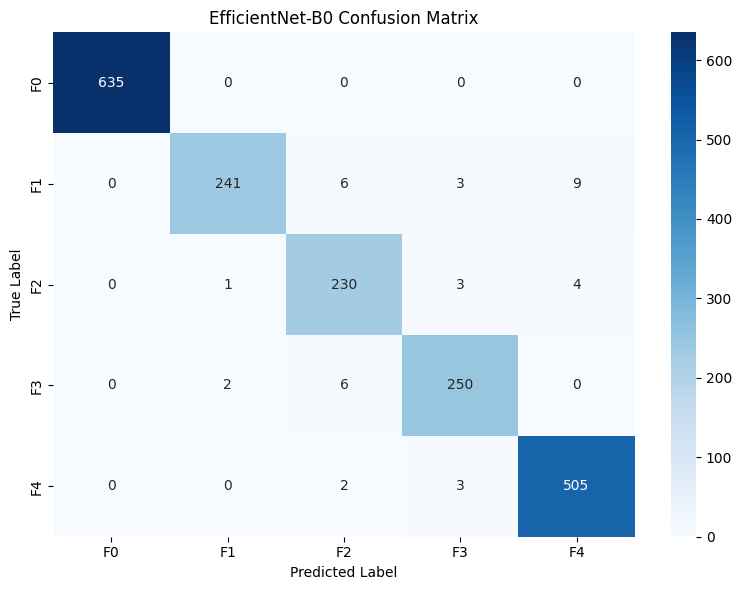

In [50]:

# Step 29: Evaluate EfficientNet-B0 on test set

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best model load
model.load_state_dict(
    torch.load(
        "/content/best_efficientnet_b0.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Test accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)
print(f"EfficientNet-B0 Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    digits=4,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9987
Weighted ROC-AUC: 0.9991


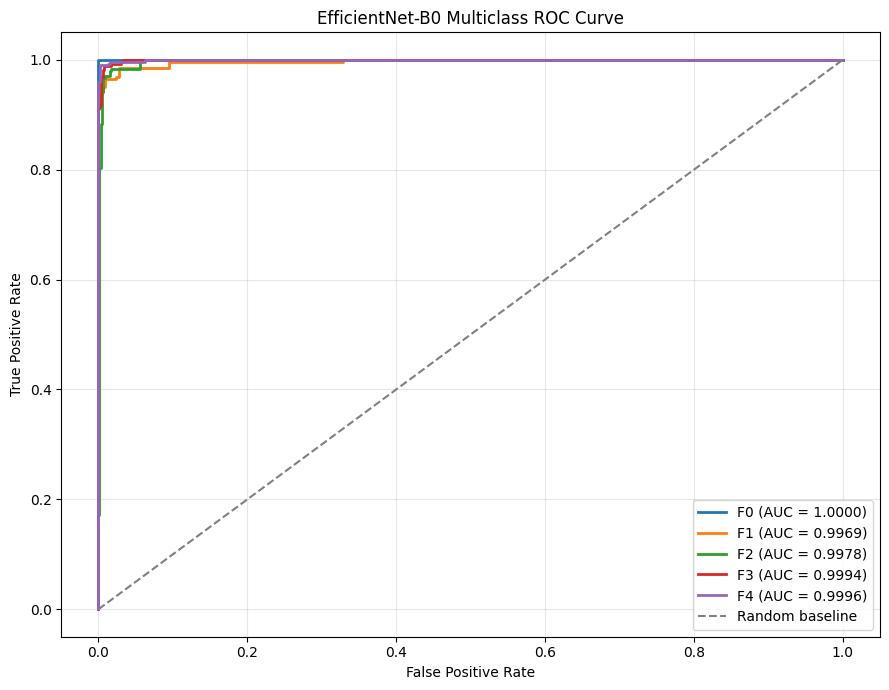

In [51]:

# Step 30: EfficientNet-B0 Multiclass ROC Curve and AUC

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Best checkpoint already model-e load kora ache
model.eval()

all_labels_roc = []
all_probs_roc = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc.extend(labels.cpu().numpy())
        all_probs_roc.extend(probabilities.cpu().numpy())

all_labels_roc = np.array(all_labels_roc)
all_probs_roc = np.array(all_probs_roc)

binary_labels = label_binarize(
    all_labels_roc,
    classes=[0, 1, 2, 3, 4]
)

macro_auc = roc_auc_score(
    binary_labels, all_probs_roc, average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels, all_probs_roc, average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Plot class-wise ROC
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs_roc[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNet-B0 Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/efficientnet_b0_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Macro ROC-AUC: 0.9987
Weighted ROC-AUC: 0.9991


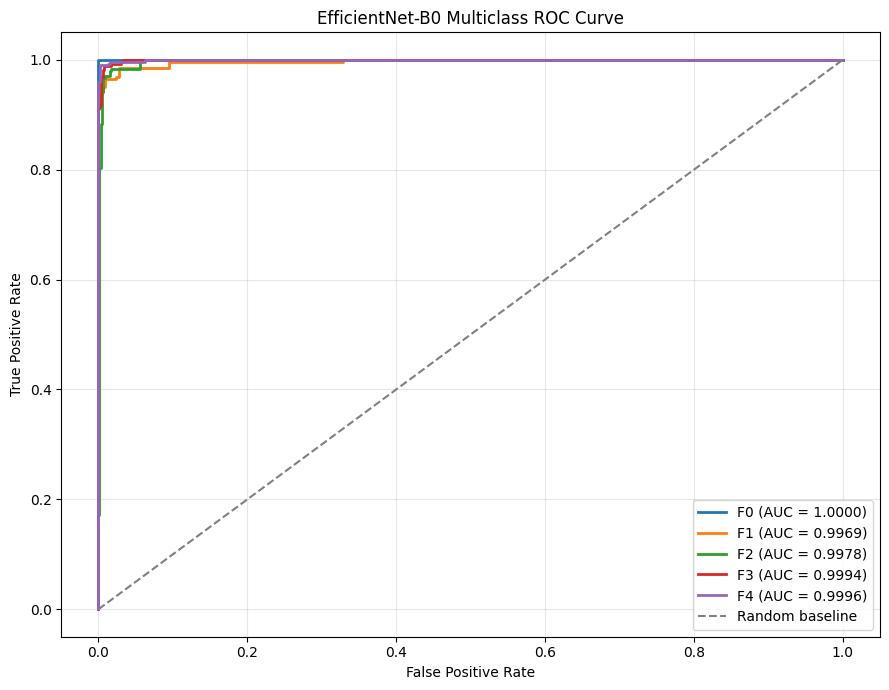

In [52]:

# Step 30: EfficientNet-B0 Multiclass ROC Curve and AUC

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Best checkpoint already model-e load kora ache
model.eval()

all_labels_roc = []
all_probs_roc = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc.extend(labels.cpu().numpy())
        all_probs_roc.extend(probabilities.cpu().numpy())

all_labels_roc = np.array(all_labels_roc)
all_probs_roc = np.array(all_probs_roc)

binary_labels = label_binarize(
    all_labels_roc,
    classes=[0, 1, 2, 3, 4]
)

macro_auc = roc_auc_score(
    binary_labels, all_probs_roc, average="macro"
)

weighted_auc = roc_auc_score(
    binary_labels, all_probs_roc, average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

# Plot class-wise ROC
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i],
        all_probs_roc[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNet-B0 Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/efficientnet_b0_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:

# Step 31.2: GhostNet model setup

import torch
import torch.nn as nn
import timm

# GPU or CPU select
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Pretrained GhostNet load, 5 output classes
model = timm.create_model(
    "ghostnet_100.in1k",
    pretrained=True,
    num_classes=5
)

model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("GhostNet setup complete!")
print("Output classes:", model.num_classes)

Device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

GhostNet setup complete!
Output classes: 5


In [54]:

# Step 32: Train and validate GhostNet

import copy
import torch

num_epochs = 10
best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # Training
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    # Best checkpoint save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_ghostnet.pth"
        )
        print("Best GhostNet model saved!")

# Restore best model
model.load_state_dict(best_model_state)

print("\nGhostNet training complete!")


Epoch [1/10]
Train Loss: 0.8745 | Train Accuracy: 0.6269
Val Loss: 0.5359 | Val Accuracy: 0.7788
Best GhostNet model saved!

Epoch [2/10]
Train Loss: 0.4617 | Train Accuracy: 0.8167
Val Loss: 0.2787 | Val Accuracy: 0.9187
Best GhostNet model saved!

Epoch [3/10]
Train Loss: 0.2709 | Train Accuracy: 0.8969
Val Loss: 0.1689 | Val Accuracy: 0.9503
Best GhostNet model saved!

Epoch [4/10]
Train Loss: 0.1576 | Train Accuracy: 0.9431
Val Loss: 0.1561 | Val Accuracy: 0.9661
Best GhostNet model saved!

Epoch [5/10]
Train Loss: 0.0939 | Train Accuracy: 0.9675
Val Loss: 0.1392 | Val Accuracy: 0.9594
Best GhostNet model saved!

Epoch [6/10]
Train Loss: 0.0561 | Train Accuracy: 0.9807
Val Loss: 0.1730 | Val Accuracy: 0.9594

Epoch [7/10]
Train Loss: 0.0464 | Train Accuracy: 0.9851
Val Loss: 0.1286 | Val Accuracy: 0.9684
Best GhostNet model saved!

Epoch [8/10]
Train Loss: 0.0297 | Train Accuracy: 0.9911
Val Loss: 0.1734 | Val Accuracy: 0.9639

Epoch [9/10]
Train Loss: 0.0226 | Train Accuracy: 0.9

GhostNet Test Accuracy: 96.63%

Classification Report:
              precision    recall  f1-score   support

          F0     0.9969    1.0000    0.9984       635
          F1     0.8961    0.9653    0.9294       259
          F2     0.9856    0.8655    0.9217       238
          F3     0.9205    0.9419    0.9310       258
          F4     0.9824    0.9843    0.9833       510

    accuracy                         0.9663      1900
   macro avg     0.9563    0.9514    0.9528      1900
weighted avg     0.9675    0.9663    0.9662      1900



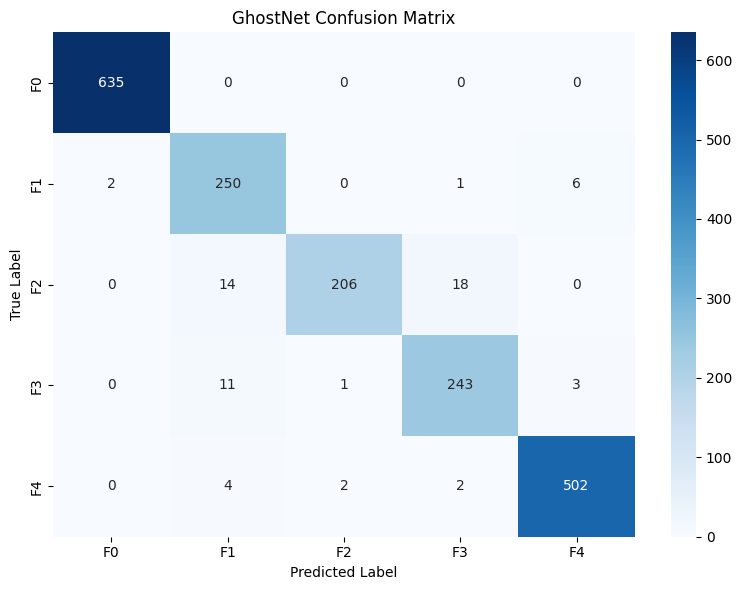

In [55]:

# Step 33: Evaluate GhostNet on test dataset

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load best checkpoint
model.load_state_dict(
    torch.load(
        "/content/best_ghostnet.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

class_names = ["F0", "F1", "F2", "F3", "F4"]
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

print(
    f"GhostNet Test Accuracy: "
    f"{accuracy_score(all_labels, all_predictions) * 100:.2f}%"
)

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GhostNet Confusion Matrix")
plt.tight_layout()
plt.show()

Macro ROC-AUC: 0.9971
Weighted ROC-AUC: 0.9980


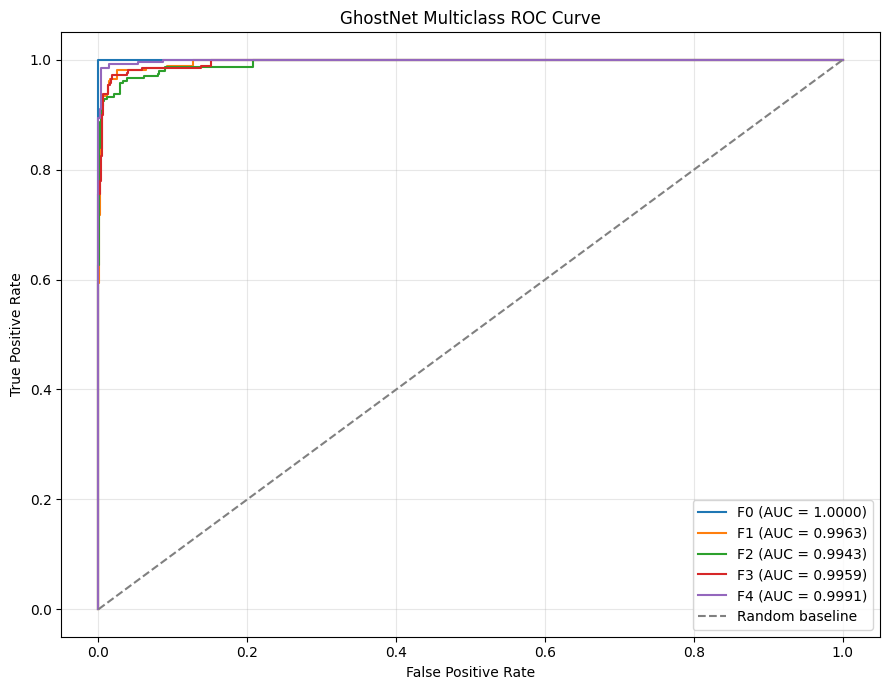

In [56]:

# Step 34: GhostNet multiclass ROC and AUC

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

model.eval()
roc_labels = []
roc_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        roc_labels.extend(labels.cpu().numpy())
        roc_probs.extend(probs.cpu().numpy())

roc_labels = np.array(roc_labels)
roc_probs = np.array(roc_probs)

binary_labels = label_binarize(
    roc_labels,
    classes=[0, 1, 2, 3, 4]
)

macro_auc = roc_auc_score(
    binary_labels, roc_probs, average="macro"
)
weighted_auc = roc_auc_score(
    binary_labels, roc_probs, average="weighted"
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

plt.figure(figsize=(9, 7))

for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        binary_labels[:, i], roc_probs[:, i]
    )
    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GhostNet Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/ghostnet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [57]:
import os
import time
import torch
import torch.nn as nn
import torchvision.models as models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 5

class_names = ["F0", "F1", "F2", "F3", "F4"]

print("Device:", device)

Device: cuda


In [58]:
# 1. MobileNetV3-Small
mobilenet = models.mobilenet_v3_small(weights=None)
mobilenet.classifier[3] = nn.Linear(
    mobilenet.classifier[3].in_features, num_classes
)

# 2. ShuffleNetV2 x0.5
shufflenet = models.shufflenet_v2_x0_5(weights=None)
shufflenet.fc = nn.Linear(
    shufflenet.fc.in_features, num_classes
)

# 3. SqueezeNet 1.1
squeezenet = models.squeezenet1_1(weights=None)
squeezenet.classifier[1] = nn.Conv2d(
    512, num_classes, kernel_size=1
)
squeezenet.num_classes = num_classes

# 4. EfficientNet-B0
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, num_classes
)

model_dict = {
    "MobileNetV3-Small": mobilenet,
    "ShuffleNetV2": shufflenet,
    "SqueezeNet1.1": squeezenet,
    "EfficientNet-B0": efficientnet
}

checkpoint_paths = {
    "MobileNetV3-Small": "/content/best_mobilenetv3_small.pth",
    "ShuffleNetV2": "/content/best_shufflenet_v2_x0_5.pth",
    "SqueezeNet1.1": "/content/best_squeezenet1_1.pth",
    "EfficientNet-B0": "/content/best_efficientnet_b0.pth"
}

for name, model in model_dict.items():
    path = checkpoint_paths[name]

    if not os.path.exists(path):
        print(f"Checkpoint missing: {name} -> {path}")
        continue

    checkpoint = torch.load(path, map_location=device)

    # Supports both saved state_dict and checkpoint dictionaries
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    # Remove DataParallel prefix if present
    checkpoint = {
        k.replace("module.", "", 1): v
        for k, v in checkpoint.items()
    }

    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()

    print(f"{name}: loaded successfully")

MobileNetV3-Small: loaded successfully
ShuffleNetV2: loaded successfully
SqueezeNet1.1: loaded successfully
EfficientNet-B0: loaded successfully


In [59]:
results = []
all_model_probs = {}
all_model_preds = {}

# Test labels are collected once
y_true = []
for images, labels in test_loader:
    y_true.extend(labels.cpu().numpy())

y_true = np.array(y_true)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

for name, model in model_dict.items():

    if not os.path.exists(checkpoint_paths[name]):
        continue

    model.eval()
    y_pred = []
    y_prob = []
    inference_start = time.perf_counter()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            y_pred.extend(
                torch.argmax(probabilities, dim=1).cpu().numpy()
            )
            y_prob.extend(probabilities.cpu().numpy())

    inference_seconds = time.perf_counter() - inference_start

    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    try:
        macro_auc = roc_auc_score(
            y_true_bin, y_prob, average="macro"
        )
        weighted_auc = roc_auc_score(
            y_true_bin, y_prob, average="weighted"
        )
    except ValueError:
        macro_auc = np.nan
        weighted_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Macro Precision (%)": precision * 100,
        "Macro Recall (%)": recall * 100,
        "Macro F1 (%)": f1 * 100,
        "Macro ROC-AUC": macro_auc,
        "Weighted ROC-AUC": weighted_auc,
        "Inference Time (s)": inference_seconds
    })

    all_model_probs[name] = y_prob
    all_model_preds[name] = y_pred

    print(f"\n===== {name} =====")
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4
    ))


===== MobileNetV3-Small =====
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9828    0.8803    0.9287       259
          F2     0.9550    0.8908    0.9217       238
          F3     0.9307    0.9884    0.9586       258
          F4     0.9441    0.9941    0.9685       510

    accuracy                         0.9668      1900
   macro avg     0.9625    0.9507    0.9555      1900
weighted avg     0.9676    0.9668    0.9664      1900


===== ShuffleNetV2 =====
              precision    recall  f1-score   support

          F0     1.0000    1.0000    1.0000       635
          F1     0.9510    0.8996    0.9246       259
          F2     0.8798    0.9538    0.9153       238
          F3     0.9562    0.9302    0.9430       258
          F4     0.9746    0.9765    0.9755       510

    accuracy                         0.9647      1900
   macro avg     0.9523    0.9520    0.9517      1900
weighted avg     0.9